<a href="https://colab.research.google.com/github/RadhaKalluri/Nowak-Kalluri_TypeIISGN2026/blob/main/Copy_of_TypeIIUMAPZdataSimplifiedwithHeatmapPaperFinal63026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# load necessary plugins and access data table, see s
!pip install openpyxl umap-learn==0.5.8
from google.colab import files

uploaded = files.upload()  # This will prompt you to upload the Excel file
import pandas as pd

# Load Excel file
df = pd.read_excel("TypeIIPaperUMAPdata.xlsx", engine="openpyxl")

import matplotlib.pyplot as plt


Saving TypeIIPaperUMAPdata.xlsx to TypeIIPaperUMAPdata (1).xlsx


In [ ]:
from sklearn.preprocessing import StandardScaler


X = df.iloc[:, :-1]  # All data except the last column
clusters = df.iloc[:, -1]  # Last column as cluster labels
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Create a DataFrame from the normalized data
# Use original column names if available
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Define the cluster labels in the last column
X_scaled_df['Cluster'] = clusters.values

# Display the first few rows in Colab
X_scaled_df.head()

,capatiance (pF),anode number,gmax400 (nS),RMP (mV),g-30400 (nS),latency (ms),threshold (pA),spike number,g10to400 ratio,Cluster
0,0.378792,-0.412082,0.149154,-0.104457,-0.206580,-0.755274,0.702158,0.534127,-0.341516,0
1,-0.375901,-0.412082,-0.361180,-0.104457,0.076438,-0.656918,0.329825,0.534127,0.138231,0
2,-0.925978,-0.412082,-0.643714,0.171131,-0.835510,-0.386923,-0.038910,0.534127,-0.302184,0
3,-0.766746,-0.412082,-0.606704,-2.033569,-0.435955,-0.259640,-0.038910,0.534127,-0.688724,0
4,0.142485,-0.412082,0.502582,-0.380044,0.113434,-0.348353,-0.571328,0.534127,-0.624057,0


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


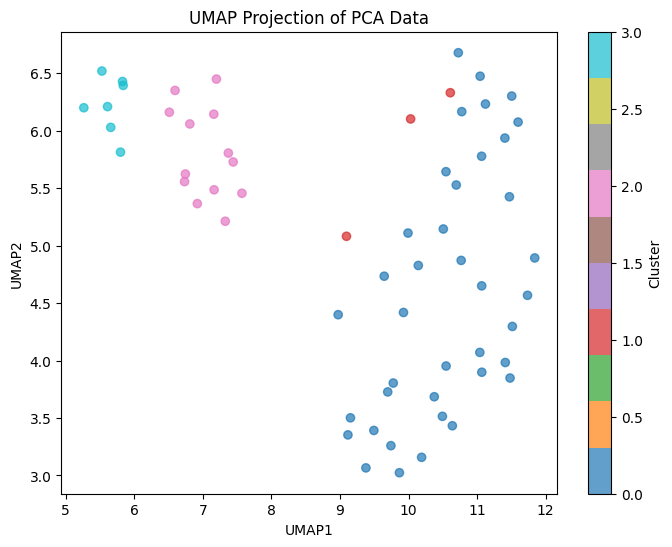

In [ ]:
import umap

# Run UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

# Plot UMAP
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters, cmap="tab10", alpha=0.7)
plt.colorbar(label="Cluster")
plt.title("UMAP Projection of PCA Data")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


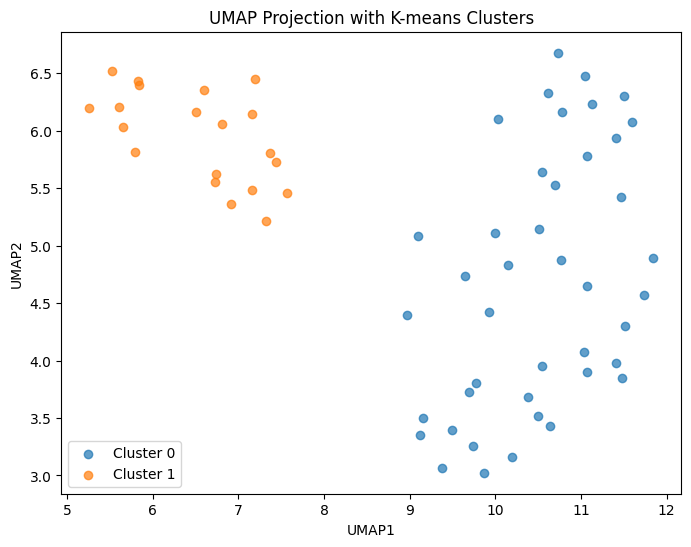

In [ ]:
import umap
import numpy as np

# Run UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

from sklearn.cluster import KMeans

# Decide number of clusters (you can change this; see later for silhouette score to determine best # of clusters)
num_clusters = 2
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_umap)  # Assign each point to a cluster
import matplotlib.pyplot as plt
import seaborn as sns

# Assign colors based on cluster labels
palette = sns.color_palette("tab10", n_colors=num_clusters)

plt.figure(figsize=(8, 6))
for i in range(num_clusters):
    idx = clusters == i
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], color=palette[i], label=f"Cluster {i}", alpha=0.7)

plt.legend()
plt.title("UMAP Projection with K-means Clusters")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()

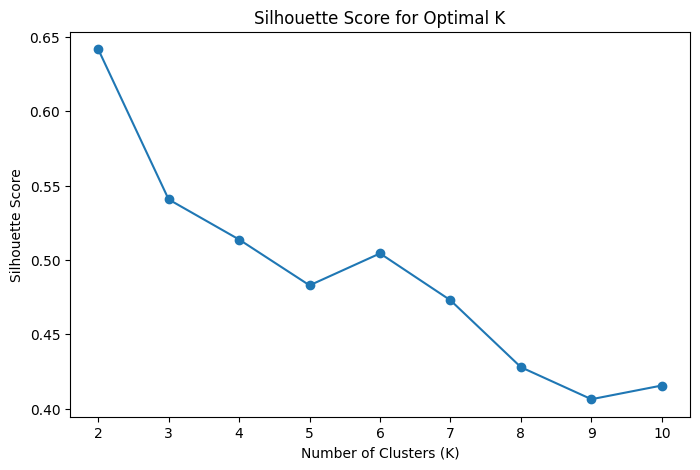

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 11):  # Silhouette score is undefined for k=1
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_umap)
    score = silhouette_score(X_umap, labels)
    sil_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), sil_scores, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal K")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_4244/1856143988.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


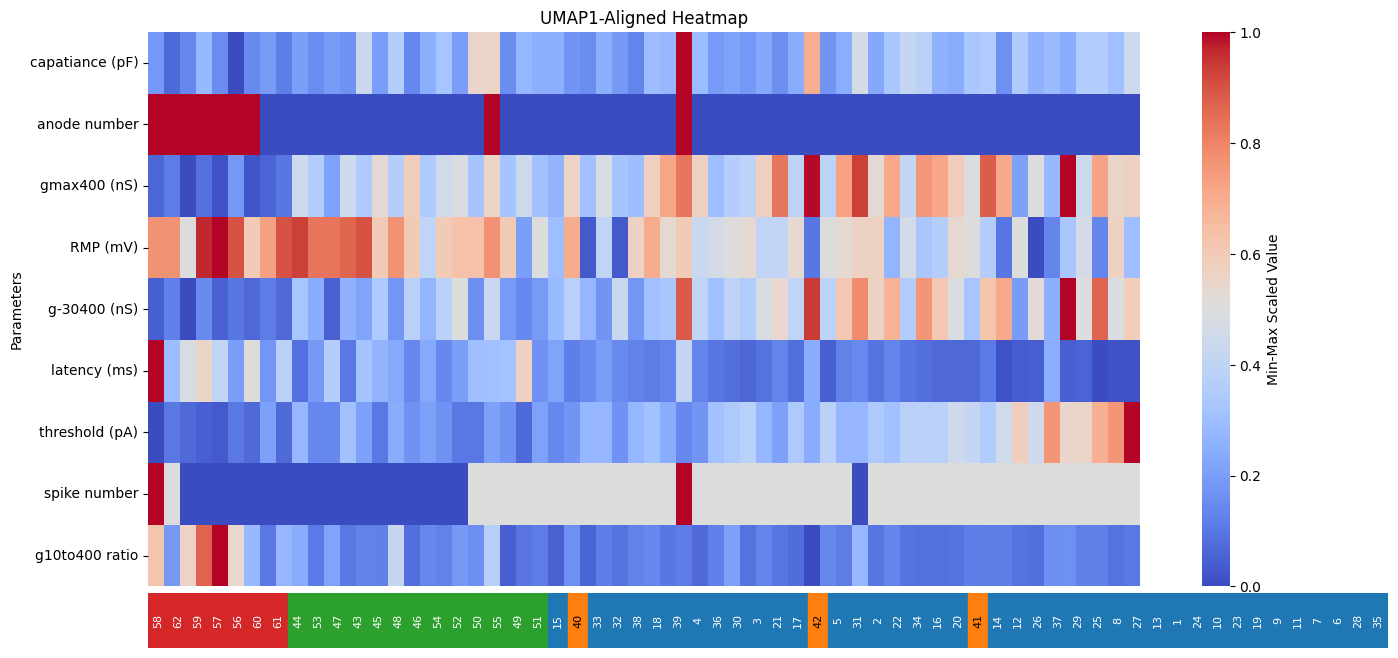

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import umap

# Load data
df = pd.read_excel("TypeIIPaperUMAPdata.xlsx", engine="openpyxl")

# Extract features and clusters
features = df.iloc[:, :-1]
clusters = df.iloc[:, -1]
original_indices = df.index.to_numpy()

# Normalize features with Min-Max scaler
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(features)
norm_df = pd.DataFrame(normalized_data, columns=features.columns)

# UMAP on standardized features
X_scaled = StandardScaler().fit_transform(features)
X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled)

# Sort by UMAP1
umap1 = X_umap[:, 0]
sorted_indices = np.argsort(umap1)

norm_df_sorted = norm_df.iloc[sorted_indices].reset_index(drop=True)
cluster_sorted = clusters.iloc[sorted_indices].reset_index(drop=True)
id_sorted = original_indices[sorted_indices] + 1  # +1 for Excel-style row numbers starting at 1

# Cluster color mapping
unique_clusters = np.unique(cluster_sorted)
cluster_colors = sns.color_palette("tab10", n_colors=len(unique_clusters))
cluster_color_map = {c: cluster_colors[i % len(cluster_colors)] for i, c in enumerate(unique_clusters)}
cluster_color_array = cluster_sorted.map(cluster_color_map).to_numpy()

# Transpose data for rotated heatmap (features as rows, cells as columns)
data_to_plot = norm_df_sorted.T

# Plotting
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[10, 1], hspace=0.02)

ax_heatmap = fig.add_subplot(gs[0])
ax_ids = fig.add_subplot(gs[1], sharex=ax_heatmap)

# Plot heatmap
sns.heatmap(data_to_plot, cmap='coolwarm', ax=ax_heatmap,
            cbar_kws={'label': 'Min-Max Scaled Value'},
            xticklabels=False, yticklabels=True)

ax_heatmap.set_ylabel("Parameters")
ax_heatmap.set_xlabel("")
ax_heatmap.set_title("UMAP1-Aligned Heatmap")

# Plot cluster color blocks below heatmap
for x, color in enumerate(cluster_color_array):
    ax_ids.add_patch(plt.Rectangle((x, 0), 1, 1, color=color))

# Add cell ID text labels centered under each block
for x, label in enumerate(id_sorted):
    ax_ids.text(x + 0.5, 0.5, str(label), ha='center', va='center', fontsize=8,
                rotation=90,
                color='white' if sum(cluster_color_array[x][:3]) < 1.5 else 'black')

# Formatting the ID axis
ax_ids.set_xlim(0, len(id_sorted))
ax_ids.set_ylim(0, 1)
ax_ids.axis('off')

plt.tight_layout()

# Save as vector PDF for Affinity Designer === remove # from next line and three lines below plt.show() to save
#fig.savefig("UMAP1_Heatmap_ClusterLabels_rotated.pdf", format='pdf', bbox_inches='tight')

# Show plot
plt.show()

#fig.savefig("UMAP1_Heatmap_ClusterLabelsTP.pdf", format='pdf', bbox_inches='tight')
#from google.colab import files
#files.download("UMAP1_Heatmap_ClusterLabelsTP.pdf")



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_4244/1602079370.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


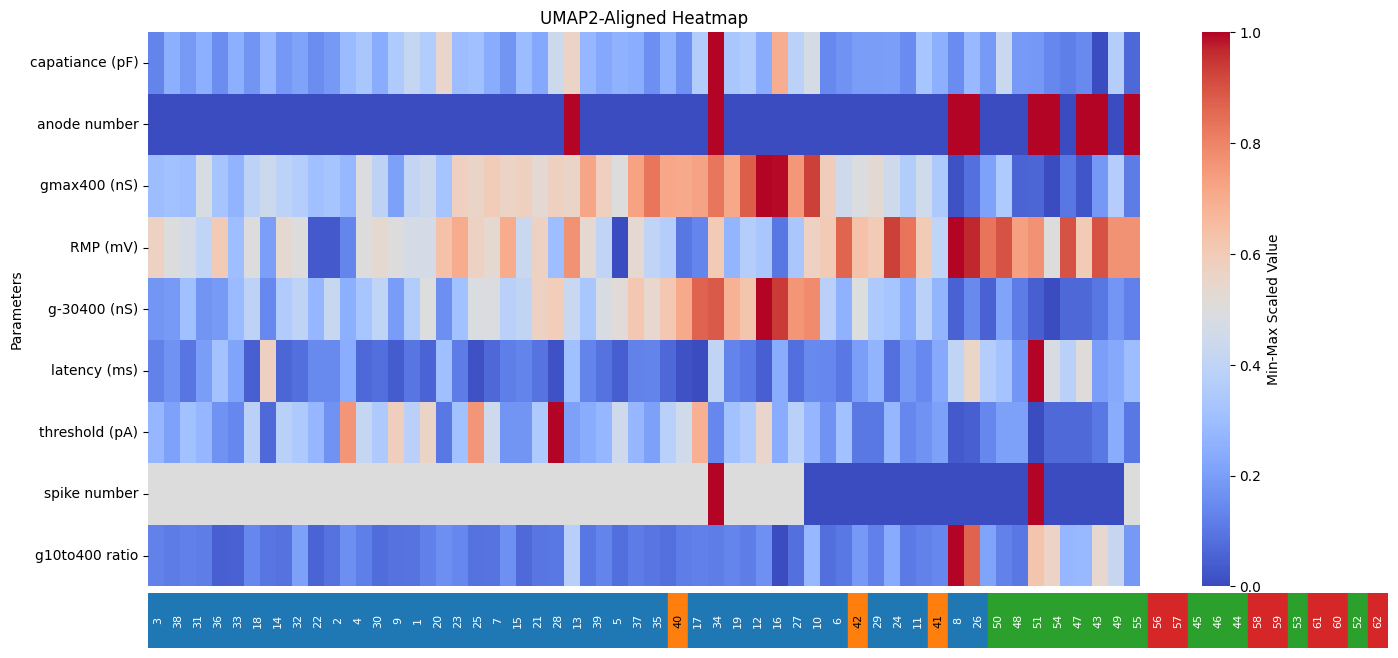

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import umap

# Load data
df = pd.read_excel("TypeIIPaperUMAPdata.xlsx", engine="openpyxl")

# Extract features and clusters
features = df.iloc[:, :-1]
clusters = df.iloc[:, -1]
original_indices = df.index.to_numpy()

# Normalize features with Min-Max scaler
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(features)
norm_df = pd.DataFrame(normalized_data, columns=features.columns)

# UMAP on standardized features
X_scaled = StandardScaler().fit_transform(features)
X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled)

# Sort by new Super-Groups then by UMAP2
umap_coords_and_clusters = pd.DataFrame({
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'Cluster': clusters.values
})

# Create a new 'SuperGroup' column for sorting
umap_coords_and_clusters['SuperGroup'] = np.where(
    (umap_coords_and_clusters['Cluster'] == 0) | (umap_coords_and_clusters['Cluster'] == 1),
    'Group 0-1', # Assign a label for the first group
    'Group 2-3'  # Assign a label for the second group (clusters 2 and 3)
)

sorted_indices = umap_coords_and_clusters.sort_values(by=['SuperGroup', 'UMAP2']).index.to_numpy()

norm_df_sorted = norm_df.iloc[sorted_indices].reset_index(drop=True)
cluster_sorted = clusters.iloc[sorted_indices].reset_index(drop=True) # Keep original clusters for coloring
id_sorted = original_indices[sorted_indices] + 1  # +1 for Excel-style row numbers starting at 1

# Cluster color mapping (based on original clusters)
unique_clusters = np.unique(cluster_sorted)
cluster_colors = sns.color_palette("tab10", n_colors=len(unique_clusters))
cluster_color_map = {c: cluster_colors[i % len(cluster_colors)] for i, c in enumerate(unique_clusters)}
cluster_color_array = cluster_sorted.map(cluster_color_map).to_numpy()

# Transpose data for rotated heatmap (features as rows, cells as columns)
data_to_plot = norm_df_sorted.T

# Plotting
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[10, 1], hspace=0.02)

ax_heatmap = fig.add_subplot(gs[0])
ax_ids = fig.add_subplot(gs[1], sharex=ax_heatmap)

# Plot heatmap
sns.heatmap(data_to_plot, cmap='coolwarm', ax=ax_heatmap,
            cbar_kws={'label': 'Min-Max Scaled Value'},
            xticklabels=False, yticklabels=True)

ax_heatmap.set_ylabel("Parameters")
ax_heatmap.set_xlabel("")
ax_heatmap.set_title("UMAP2-Aligned Heatmap")

# Plot cluster color blocks below heatmap
for x, color in enumerate(cluster_color_array):
    ax_ids.add_patch(plt.Rectangle((x, 0), 1, 1, color=color))

# Add cell ID text labels centered under each block
for x, label in enumerate(id_sorted):
    ax_ids.text(x + 0.5, 0.5, str(label), ha='center', va='center', fontsize=8,
                rotation=90,
                color='white' if sum(cluster_color_array[x][:3]) < 1.5 else 'black')

# Formatting the ID axis
ax_ids.set_xlim(0, len(id_sorted))
ax_ids.set_ylim(0, 1)
ax_ids.axis('off')

plt.tight_layout()

# Save as vector PDF for Affinity Designer === remove # from next line and three lines below plt.show() to save
#fig.savefig("UMAP_SuperGroup_UMAP2_Aligned_Heatmap.pdf", format='pdf', bbox_inches='tight')

# Show plot
plt.show()

#fig.savefig("UMAP2_Aligned_Heatmap.pdf", format='pdf', bbox_inches='tight')
#from google.colab import files
#files.download("UMAP2_Aligned_Heatmap.pdf")
